# Skill Polarization and Human-Capital Migration Drift

This notebook analyzes Sri Lanka migration skill composition (1994-2025) using clean, reproducible steps.

Main focus:
- Track movement toward higher-skill vs low-skill migration composition.
- Evaluate gender-specific drift in skill shares.
- Examine trend direction and possible structural shifts around 2018 and 2020.

## 1. Environment Setup and Imports

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple, Dict

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy.stats import theilslopes, f
from statsmodels.robust.norms import HuberT
from statsmodels.tsa.stattools import adfuller
from statsmodels.nonparametric.smoothers_lowess import lowess

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='talk')

## 2. Configuration and Constants

In [2]:
@dataclass(frozen=True)
class AnalysisConfig:
    data_path: Path = Path('SriLanka_Migration_Dinura_Chanupa.csv')
    expected_start_year: int = 1994
    expected_end_year: int = 2025
    rounding_tolerance: float = 0.1
    lowess_frac: float = 0.4
    break_years: Tuple[int, int] = (2018, 2020)


CONFIG = AnalysisConfig()

REQUIRED_COLUMNS: List[str] = [
    'year',
    'total_skilled_perc',
    'total_lowskilled_perc',
    'male_skilled_perc',
    'male_lowskilled_perc',
    'female_skilled_perc',
    'female_lowskilled_perc',
]

TREND_VARIABLES: List[str] = [
    'total_skilled_perc',
    'total_lowskilled_perc',
    'male_skilled_perc',
    'male_lowskilled_perc',
    'female_skilled_perc',
    'female_lowskilled_perc',
    'OPI',
    'MPI',
    'FPI',
    'SMQI',
]

print(CONFIG)

AnalysisConfig(data_path=WindowsPath('SriLanka_Migration_Dinura_Chanupa.csv'), expected_start_year=1994, expected_end_year=2025, rounding_tolerance=0.1, lowess_frac=0.4, break_years=(2018, 2020))


## 3. Core Data Model Definitions

In [3]:
@dataclass
class TrendResult:
    variable: str
    ols_slope: float
    ols_ci_low: float
    ols_ci_high: float
    huber_slope: float
    theil_sen_slope: float
    theil_sen_ci_low: float
    theil_sen_ci_high: float


@dataclass
class BreakTestResult:
    variable: str
    break_year: int
    f_stat: float
    p_value: float
    slope_pre: float
    slope_post: float

## 4. Utility Function Implementation

In [4]:
def load_skill_data(config: AnalysisConfig) -> pd.DataFrame:
    if not config.data_path.exists():
        raise FileNotFoundError(f'Data file not found: {config.data_path}')

    df = pd.read_csv(config.data_path)

    alias_map = {
        'male_skilled_pct_annual': 'male_skilled_perc',
        'male_lowskilled_pct_annual': 'male_lowskilled_perc',
        'female_skilled_pct_annual': 'female_skilled_perc',
        'female_lowskilled_pct_annual': 'female_lowskilled_perc',
    }
    available_aliases = {k: v for k, v in alias_map.items() if k in df.columns and v not in df.columns}
    if available_aliases:
        df = df.rename(columns=available_aliases)

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    return df[REQUIRED_COLUMNS].sort_values('year').reset_index(drop=True)


def build_validation_table(df: pd.DataFrame, config: AnalysisConfig) -> pd.DataFrame:
    expected_years = set(range(config.expected_start_year, config.expected_end_year + 1))
    observed_years = set(df['year'].astype(int).tolist())

    continuous_years = expected_years == observed_years
    duplicate_years = int(df['year'].duplicated().sum())

    bounded = True
    for c in REQUIRED_COLUMNS:
        if c == 'year':
            continue
        if ((df[c] < 0) | (df[c] > 100)).any():
            bounded = False
            break

    total_identity = np.abs(df['total_skilled_perc'] + df['total_lowskilled_perc'] - 100)
    male_identity = np.abs(df['male_skilled_perc'] + df['male_lowskilled_perc'] - 100)
    female_identity = np.abs(df['female_skilled_perc'] + df['female_lowskilled_perc'] - 100)

    checks = [
        ('Year continuity 1994-2025', continuous_years, 'All expected years present'),
        ('Duplicate years', duplicate_years == 0, f'Duplicates: {duplicate_years}'),
        ('Value bounds [0, 100]', bounded, 'All percentages within bounds'),
        ('Identity total skill + low-skill', bool((total_identity <= config.rounding_tolerance).all()), f'Max abs error: {total_identity.max():.4f}'),
        ('Identity male skill + low-skill', bool((male_identity <= config.rounding_tolerance).all()), f'Max abs error: {male_identity.max():.4f}'),
        ('Identity female skill + low-skill', bool((female_identity <= config.rounding_tolerance).all()), f'Max abs error: {female_identity.max():.4f}'),
    ]

    return pd.DataFrame(checks, columns=['check', 'passed', 'detail'])


def enforce_validation(validation_table: pd.DataFrame) -> None:
    failed = validation_table[~validation_table['passed']]
    if not failed.empty:
        raise ValueError('Validation failed.\n' + failed.to_string(index=False))


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['OPI'] = (out['total_skilled_perc'] - out['total_lowskilled_perc']).abs()
    out['MPI'] = (out['male_skilled_perc'] - out['male_lowskilled_perc']).abs()
    out['FPI'] = (out['female_skilled_perc'] - out['female_lowskilled_perc']).abs()
    out['CPG'] = out['FPI'] - out['MPI']
    out['SMQI'] = out['total_skilled_perc'] / out['total_lowskilled_perc'].replace(0, np.nan)
    out['t'] = np.arange(len(out), dtype=float)
    out['t_c'] = out['t'] - out['t'].mean()
    return out


def fit_ols_trend(y: pd.Series, x: pd.Series) -> Tuple[float, float, float]:
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    slope = float(model.params.iloc[1])
    ci_low = float(model.conf_int().iloc[1, 0])
    ci_high = float(model.conf_int().iloc[1, 1])
    return slope, ci_low, ci_high


def fit_huber_trend(y: pd.Series, x: pd.Series) -> float:
    X = sm.add_constant(x)
    model = sm.RLM(y, X, M=HuberT()).fit()
    return float(model.params.iloc[1])


def fit_theil_sen(y: pd.Series, x: pd.Series) -> Tuple[float, float, float]:
    slope, intercept, low, high = theilslopes(y.values, x.values, alpha=0.95)
    return float(slope), float(low), float(high)


def build_trend_table(df: pd.DataFrame, variables: List[str]) -> pd.DataFrame:
    rows: List[TrendResult] = []
    for var in variables:
        ols_slope, ols_low, ols_high = fit_ols_trend(df[var], df['t_c'])
        huber_slope = fit_huber_trend(df[var], df['t_c'])
        ts_slope, ts_low, ts_high = fit_theil_sen(df[var], df['t'])
        rows.append(
            TrendResult(
                variable=var,
                ols_slope=ols_slope,
                ols_ci_low=ols_low,
                ols_ci_high=ols_high,
                huber_slope=huber_slope,
                theil_sen_slope=ts_slope,
                theil_sen_ci_low=ts_low,
                theil_sen_ci_high=ts_high,
            )
        )

    trend_table = pd.DataFrame([r.__dict__ for r in rows])
    trend_table['direction_theil_sen'] = np.where(trend_table['theil_sen_slope'] > 0, 'Increasing', 'Decreasing')
    return trend_table


def run_adf_suite(df: pd.DataFrame, variables: List[str]) -> pd.DataFrame:
    rows = []
    for var in variables:
        stat, p_val, lags, nobs, _, _ = adfuller(df[var], regression='ct', autolag='AIC')
        rows.append({
            'variable': var,
            'adf_stat': float(stat),
            'p_value': float(p_val),
            'lags': int(lags),
            'n_obs': int(nobs),
            'stationary_at_5pct': bool(p_val < 0.05),
        })
    return pd.DataFrame(rows)


def chow_test(y: pd.Series, x: pd.Series, break_idx: int) -> Tuple[float, float, float, float]:
    X_full = sm.add_constant(x)
    model_full = sm.OLS(y, X_full).fit()
    rss_full = float(np.sum(model_full.resid ** 2))
    k = X_full.shape[1]
    n = len(y)

    y1, y2 = y.iloc[: break_idx + 1], y.iloc[break_idx + 1 :]
    X1, X2 = X_full[: break_idx + 1], X_full[break_idx + 1 :]

    model1 = sm.OLS(y1, X1).fit()
    model2 = sm.OLS(y2, X2).fit()
    rss_split = float(np.sum(model1.resid ** 2) + np.sum(model2.resid ** 2))

    numerator = (rss_full - rss_split) / k
    denominator = rss_split / (n - 2 * k)
    f_stat = float(numerator / denominator)
    p_val = float(1 - f.cdf(f_stat, k, n - 2 * k))

    slope_pre = float(model1.params.iloc[1])
    slope_post = float(model2.params.iloc[1])
    return f_stat, p_val, slope_pre, slope_post


def build_break_table(df: pd.DataFrame, variables: List[str], break_years: Tuple[int, int]) -> pd.DataFrame:
    rows: List[BreakTestResult] = []
    for var in variables:
        for byear in break_years:
            if byear not in df['year'].values:
                continue
            bidx = int(df.index[df['year'] == byear][0])
            f_stat, p_val, slope_pre, slope_post = chow_test(df[var], df['t_c'], bidx)
            rows.append(BreakTestResult(var, byear, f_stat, p_val, slope_pre, slope_post))

    return pd.DataFrame([r.__dict__ for r in rows])


def build_subperiod_trends(df: pd.DataFrame) -> pd.DataFrame:
    periods = [('1994-2017', 1994, 2017), ('2018-2019', 2018, 2019), ('2020-2025', 2020, 2025)]
    vars_for_sub = ['total_skilled_perc', 'total_lowskilled_perc', 'male_skilled_perc', 'female_skilled_perc', 'OPI', 'MPI', 'FPI']

    rows = []
    for label, start, end in periods:
        sub = df[(df['year'] >= start) & (df['year'] <= end)].copy()
        if len(sub) < 2:
            continue
        for var in vars_for_sub:
            slope, ci_low, ci_high = fit_theil_sen(sub[var], sub['t'])
            rows.append({'period': label, 'variable': var, 'theil_sen_slope': slope, 'ci_low': ci_low, 'ci_high': ci_high})

    return pd.DataFrame(rows)


def plot_publication_figures(df: pd.DataFrame, config: AnalysisConfig) -> None:
    fig1, axes = plt.subplots(2, 2, figsize=(16, 10))
    panel_vars = ['total_skilled_perc', 'total_lowskilled_perc', 'male_skilled_perc', 'female_skilled_perc']
    for ax, var in zip(axes.flatten(), panel_vars):
        ax.plot(df['year'], df[var], marker='o', linewidth=1.8, alpha=0.8, label=var)
        smooth = lowess(df[var], df['year'], frac=config.lowess_frac, it=2)
        ax.plot(smooth[:, 0], smooth[:, 1], linestyle='--', linewidth=2.0, label='LOWESS')
        ax.axvline(config.break_years[0], color='tab:orange', linestyle=':', linewidth=1.5)
        ax.axvline(config.break_years[1], color='tab:red', linestyle=':', linewidth=1.5)
        ax.set_title(var)
        ax.set_xlabel('Year')
        ax.set_ylabel('Percentage')
        ax.legend(loc='best', fontsize=9)
    fig1.suptitle('Figure 01(Skill Composition Trends with Structural Markers)', y=1.02)
    fig1.tight_layout()
    plt.show()

    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
    axes2[0].plot(df['year'], df['OPI'], marker='o', label='OPI')
    axes2[0].plot(df['year'], df['MPI'], marker='s', label='MPI')
    axes2[0].plot(df['year'], df['FPI'], marker='^', label='FPI')
    axes2[0].axvline(config.break_years[0], color='tab:orange', linestyle=':')
    axes2[0].axvline(config.break_years[1], color='tab:red', linestyle=':')
    axes2[0].set_title('Polarization Indices')
    axes2[0].set_xlabel('Year')
    axes2[0].set_ylabel('Index')
    axes2[0].legend()

    axes2[1].plot(df['year'], df['SMQI'], marker='D', color='teal', label='SMQI')
    smooth_smqi = lowess(df['SMQI'], df['year'], frac=config.lowess_frac, it=2)
    axes2[1].plot(smooth_smqi[:, 0], smooth_smqi[:, 1], linestyle='--', color='teal', label='LOWESS')
    axes2[1].axhline(1.0, color='gray', linestyle=':', linewidth=1.2)
    axes2[1].set_title('Skill Migration Quality Index')
    axes2[1].set_xlabel('Year')
    axes2[1].set_ylabel('Skilled / Low-skilled')
    axes2[1].legend()
    fig2.suptitle('Figure 02(Polarization Indices and Skill Migration Quality Index)', y=1.04)
    fig2.tight_layout()
    plt.show()

    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
    axes3[0].plot(df['year'], df['male_skilled_perc'], marker='o', label='Male skilled')
    axes3[0].plot(df['year'], df['female_skilled_perc'], marker='s', label='Female skilled')
    axes3[0].axvline(config.break_years[0], color='tab:orange', linestyle=':')
    axes3[0].axvline(config.break_years[1], color='tab:red', linestyle=':')
    axes3[0].set_title('Gender Drift in Skilled Share')
    axes3[0].set_xlabel('Year')
    axes3[0].set_ylabel('Skilled share (%)')
    axes3[0].legend()

    axes3[1].plot(df['year'], df['male_lowskilled_perc'], marker='o', label='Male low-skilled')
    axes3[1].plot(df['year'], df['female_lowskilled_perc'], marker='s', label='Female low-skilled')
    axes3[1].axvline(config.break_years[0], color='tab:orange', linestyle=':')
    axes3[1].axvline(config.break_years[1], color='tab:red', linestyle=':')
    axes3[1].set_title('Gender Drift in Low-skilled Share')
    axes3[1].set_xlabel('Year')
    axes3[1].set_ylabel('Low-skilled share (%)')
    axes3[1].legend()
    fig3.suptitle('Figure 03(Gender Drift in Skilled and Low-skilled Shares)', y=1.04)
    fig3.tight_layout()
    plt.show()

## 5. Primary Workflow Implementation

In [5]:
def run_skill_polarization_workflow(config: AnalysisConfig) -> Dict[str, pd.DataFrame]:
    df = load_skill_data(config)

    validation_table = build_validation_table(df, config)
    enforce_validation(validation_table)

    df_features = engineer_features(df)
    trend_table = build_trend_table(df_features, TREND_VARIABLES)

    adf_vars = ['total_skilled_perc', 'total_lowskilled_perc', 'male_skilled_perc', 'female_skilled_perc', 'OPI', 'MPI', 'FPI']
    adf_table = run_adf_suite(df_features, adf_vars)

    break_vars = ['total_skilled_perc', 'OPI']
    break_table = build_break_table(df_features, break_vars, config.break_years)

    subperiod_table = build_subperiod_trends(df_features)

    plot_publication_figures(df_features, config)

    return {
        'df_features': df_features,
        'validation_table': validation_table,
        'trend_table': trend_table,
        'adf_table': adf_table,
        'break_table': break_table,
        'subperiod_table': subperiod_table,
    }

## 6. Validation and Error Handling

In [6]:
def run_with_error_handling(config: AnalysisConfig) -> Dict[str, pd.DataFrame] | None:
    try:
        return run_skill_polarization_workflow(config)
    except FileNotFoundError as err:
        print(f'File error: {err}')
    except ValueError as err:
        print('Validation error encountered:')
        print(err)
    except Exception as err:
        print('Unexpected runtime error encountered:')
        print(type(err).__name__, str(err))
    return None

## 7. Smoke Test and Unit Test Cells

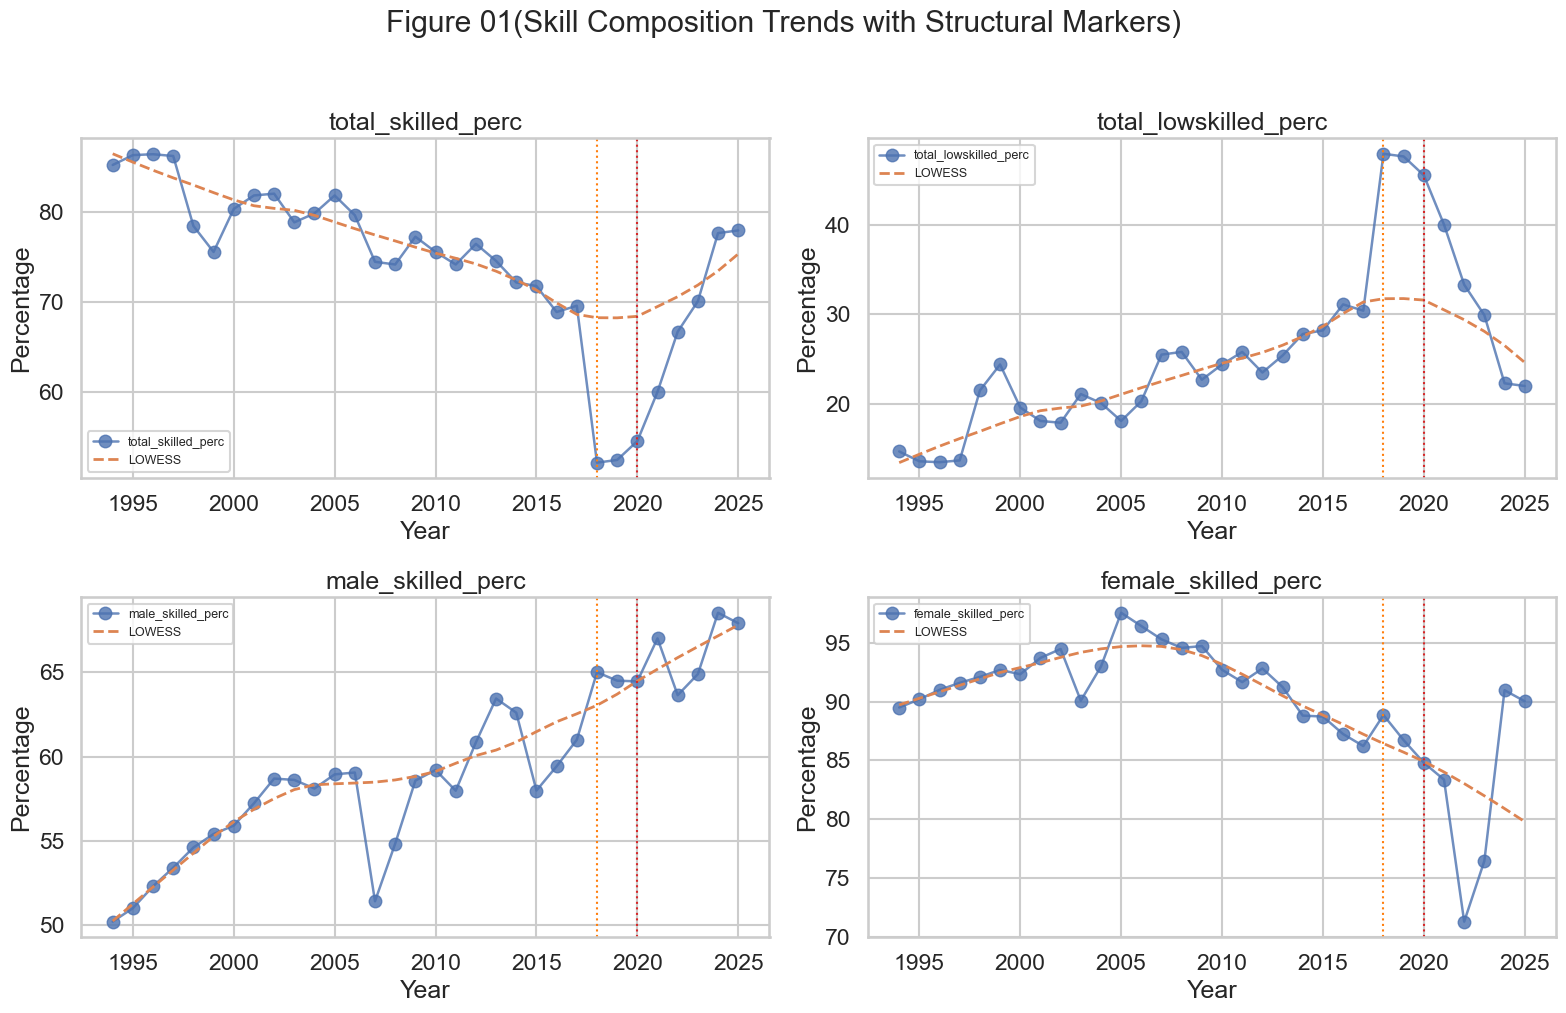

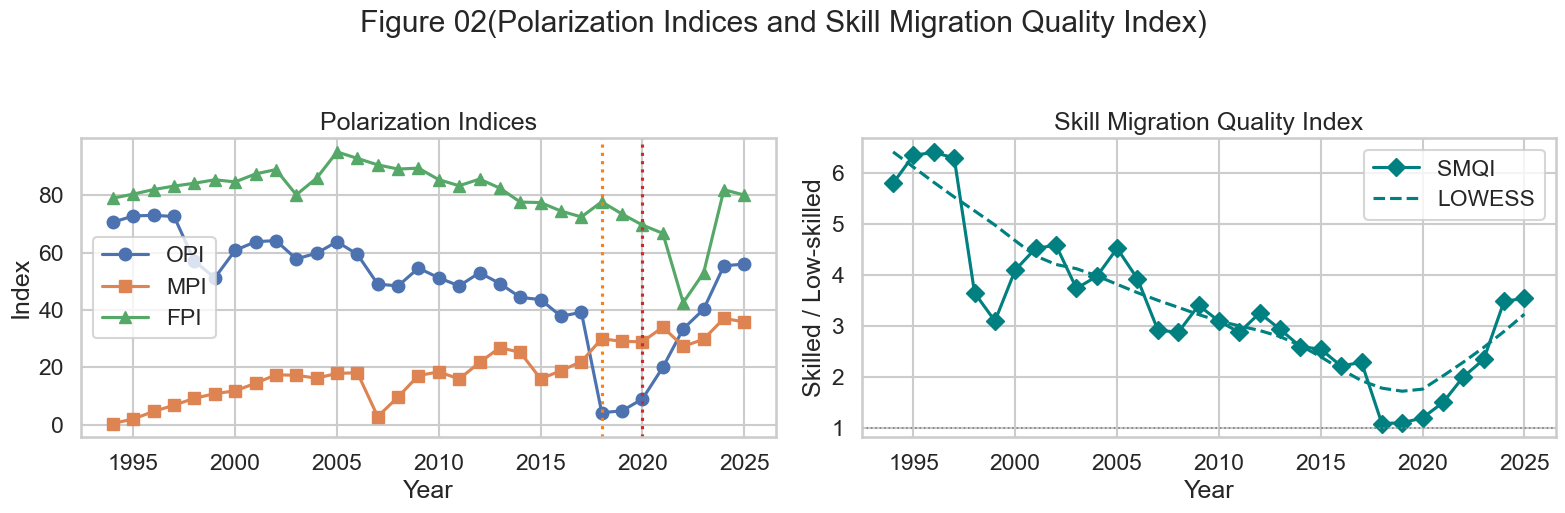

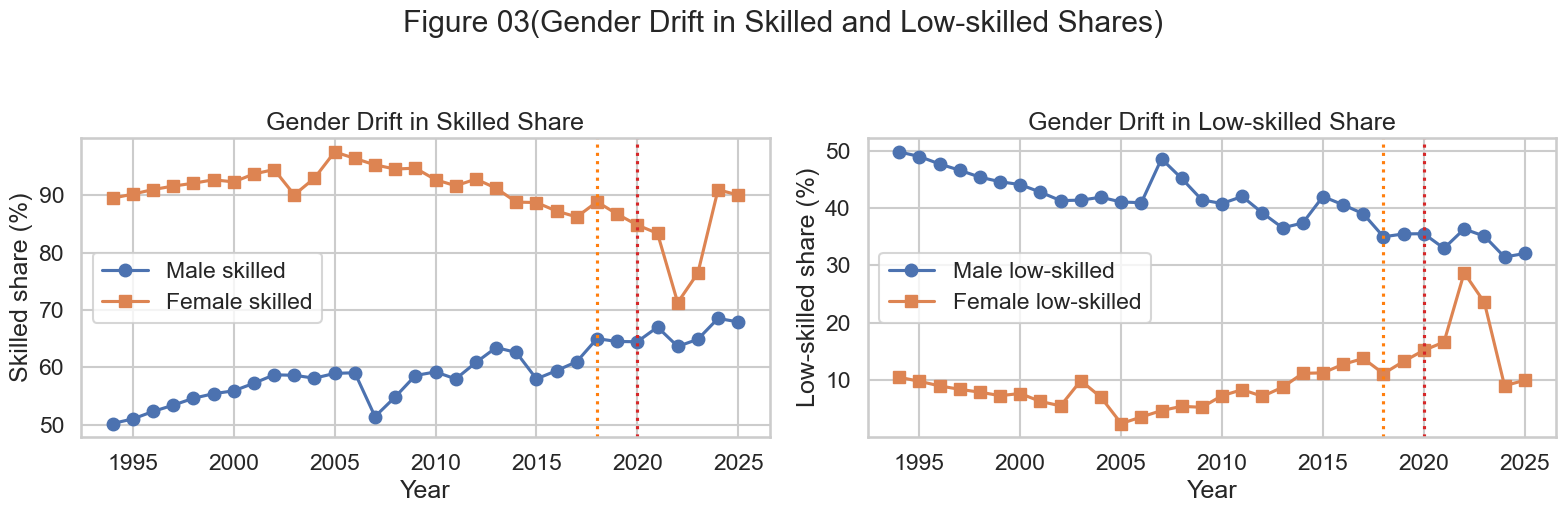

,check,passed,detail
0,Year continuity 1994-2025,True,All expected years present
1,Duplicate years,True,Duplicates: 0
2,"Value bounds [0, 100]",True,All percentages within bounds
3,Identity total skill + low-skill,True,Max abs error: 0.0000
4,Identity male skill + low-skill,True,Max abs error: 0.0000
5,Identity female skill + low-skill,True,Max abs error: 0.0000


,variable,ols_slope,ols_ci_low,ols_ci_high,huber_slope,theil_sen_slope,theil_sen_ci_low,theil_sen_ci_high,direction_theil_sen
0,total_skilled_perc,-0.703794,-0.958143,-0.449445,-0.674563,-0.686607,-0.830769,-0.511111,Decreasing
1,total_lowskilled_perc,0.703794,0.449445,0.958143,0.674563,0.686607,0.511111,0.830769,Increasing
2,male_skilled_perc,0.474567,0.386748,0.562387,0.472614,0.492910,0.411667,0.574286,Increasing
3,male_lowskilled_perc,-0.474567,-0.562387,-0.386748,-0.472614,-0.492910,-0.574286,-0.411667,Decreasing
4,female_skilled_perc,-0.323338,-0.499818,-0.146857,-0.238549,-0.254020,-0.481250,-0.092000,Decreasing
5,female_lowskilled_perc,0.323338,0.146857,0.499818,0.238549,0.254020,0.092000,0.481250,Increasing
6,OPI,-1.407588,-1.916286,-0.898890,-1.349127,-1.373214,-1.661538,-1.022222,Decreasing
7,MPI,0.949135,0.773496,1.124774,0.945228,0.985820,0.823333,1.148571,Increasing
8,FPI,-0.646675,-0.999636,-0.293714,-0.477099,-0.508039,-0.962500,-0.184000,Decreasing
9,SMQI,-0.122436,-0.157153,-0.087719,-0.136867,-0.132459,-0.166717,-0.091568,Decreasing


,variable,break_year,f_stat,p_value,slope_pre,slope_post
0,total_skilled_perc,2018,28.581472,1.724659e-07,-0.814308,4.760714
1,total_skilled_perc,2020,13.338928,8.528088e-05,-1.005006,4.700000
2,OPI,2018,28.581472,1.724659e-07,-1.628615,9.521429
3,OPI,2020,13.338928,8.528088e-05,-2.010012,9.400000


,period,variable,theil_sen_slope,ci_low,ci_high
0,1994-2017,total_skilled_perc,-0.692857,-0.812500,-0.533333
1,1994-2017,total_lowskilled_perc,0.692857,0.533333,0.812500
2,1994-2017,male_skilled_perc,0.439688,0.267778,0.593333
3,1994-2017,female_skilled_perc,-0.076750,-0.294545,0.164000
4,1994-2017,OPI,-1.385714,-1.625000,-1.066667
5,1994-2017,MPI,0.879375,0.535556,1.186667
6,1994-2017,FPI,-0.153500,-0.589091,0.328000
7,2018-2019,total_skilled_perc,0.300000,0.300000,0.300000
8,2018-2019,total_lowskilled_perc,-0.300000,-0.300000,-0.300000
9,2018-2019,male_skilled_perc,-0.500000,-0.500000,-0.500000


Key trend summary:
- total_skilled_perc Theil-Sen slope: -0.687 pp/year
- total_lowskilled_perc Theil-Sen slope: 0.687 pp/year
- OPI Theil-Sen slope: -1.373 pp/year
Notebook checks passed.


In [7]:
results = run_with_error_handling(CONFIG)

if results is not None:
    df_result = results['df_features']
    validation_table = results['validation_table']
    trend_table = results['trend_table']
    break_table = results['break_table']
    subperiod_table = results['subperiod_table']

    display(validation_table)
    display(trend_table)
    display(break_table)
    display(subperiod_table)

    assert validation_table['passed'].all(), 'One or more validation checks failed.'
    assert {'OPI', 'MPI', 'FPI', 'SMQI'}.issubset(df_result.columns), 'Derived metric columns are missing.'

    np.testing.assert_allclose(
        df_result['OPI'].values,
        np.abs(df_result['total_skilled_perc'] - df_result['total_lowskilled_perc']).values,
        rtol=0,
        atol=1e-10,
    )

    ts = trend_table.set_index('variable')
    print('Key trend summary:')
    print(f"- total_skilled_perc Theil-Sen slope: {ts.loc['total_skilled_perc', 'theil_sen_slope']:.3f} pp/year")
    print(f"- total_lowskilled_perc Theil-Sen slope: {ts.loc['total_lowskilled_perc', 'theil_sen_slope']:.3f} pp/year")
    print(f"- OPI Theil-Sen slope: {ts.loc['OPI', 'theil_sen_slope']:.3f} pp/year")

    print('Notebook checks passed.')
else:
    print('Smoke test skipped because workflow did not complete.')